In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import os, sys
%matplotlib inline

from IPython.display import display, HTML

if (sys.version_info < (3, 0)):
    HTML('''<script>
    code_show=true; 
    function code_toggle() {
     if (code_show){
     $('div.input').hide();
     } else {
     $('div.input').show();
     }
     code_show = !code_show
    } 
    $( document ).ready(code_toggle);
    </script>
    <form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')


In [2]:
working_dir = r'../../../../outputs/agg/dash'
pd.options.display.float_format = '{:0,.0f}'.format
format_percent = "{:,.2%}".format

In [3]:
def load_data(fname):
    """ open and join model and survey data """

    df_model = pd.read_csv(os.path.join(working_dir,fname+'.csv'))
    df_model['source'] = 'model'
    df_survey = pd.read_csv(os.path.join(working_dir,'survey',fname+'.csv'))
    df_survey['source'] = 'survey'
    df = pd.concat([df_model, df_survey], ignore_index=True)
    # df = df_model.append(df_survey)

    return df

# Total Persons

In [4]:
df = load_data('person_type')
df.groupby('source').sum()[['psexpfac']].T

source,model,survey
psexpfac,"4,356,019","3,933,653"


# Total Households

In [5]:
df = load_data('household_size_vehs_workers')
df.groupby('source').sum()[['hhexpfac']].T

source,model,survey
hhexpfac,"1,736,129","1,690,793"


# Total Trips

In [6]:
df = load_data('trip_total')
df.groupby('source').sum()[['trexpfac']].T

source,model,survey
trexpfac,"16,299,025","13,902,503"


# Total Tours

In [7]:
df = load_data('tour_purpose_mode')
df.groupby('source').sum()[['toexpfac']].T

source,model,survey
toexpfac,"5,821,612","5,050,722"


## Average Household Size

In [8]:
pd.options.display.float_format = '{:0,.2f}'.format
df = load_data('household_size_vehs_workers')
pd.DataFrame(
    df.groupby('source').apply(
        lambda row: ((row['hhsize']*1.0*row['hhexpfac']*1.0).sum())/row['hhexpfac'].sum()*1.0),
        columns=['avg_hh_size'])

,avg_hh_size
source,
model,2.51
survey,2.45


## Average Trips per Person

## Average Distance to Work

In [9]:
df = load_data('trip_averages')
df[df['dpurp'] == 'Work'].groupby(['mode','source']).mean(numeric_only=True)

travdist  travtime  travcost
mode       source                              
Bike       model       4.83     32.19      0.00
           survey      3.23     19.38      0.00
HOV2       model       9.71     20.98      2.13
           survey      6.81     16.70      0.04
HOV3+      model      10.45     22.00      2.28
           survey     11.60     22.57      0.30
SOV        model       9.49     21.47      2.02
           survey      8.63     19.75      0.18
School Bus model       3.06     10.03      0.61
TNC        model       6.33     17.50      1.43
           survey      3.57     13.23      0.01
Transit    model      11.35     41.60      2.66
           survey      7.11     34.18      3.09
Walk       model       0.73     14.57      0.00
           survey      0.90     18.15      0.00

## Average Distance to School

In [10]:
df[df['dpurp'] == 'School'].groupby(['mode','source']).mean(numeric_only=True)

travdist  travtime  travcost
mode       source                              
Bike       model       2.45     16.34      0.00
           survey      2.01     12.10      0.00
HOV2       model       4.67     12.21      0.96
           survey      3.46     11.12      0.06
HOV3+      model       5.30     13.05      1.09
           survey      4.20     11.94      0.01
SOV        model       5.84     15.33      1.22
           survey      8.77     19.05      0.33
School Bus model       5.68     13.64      1.17
           survey      3.11     10.12      0.00
TNC        model       1.99      9.52      0.40
           survey      3.14      9.61      0.00
Transit    model       5.84     34.60      0.20
           survey      6.91     21.60      3.00
Walk       model       1.25     24.91      0.00
           survey      0.77     15.53      0.00

## Transit Pass Ownership

In [11]:
pd.options.display.float_format = '{:0,.0f}'.format
df = load_data('parking_transit_pass')
pd.pivot_table(df, index='ptpass',columns='source',values='psexpfac',aggfunc='sum')

source,model,survey
ptpass,,
0,"3,445,624","2,864,015"
1,"910,395","1,069,639"


In [12]:
pd.pivot_table(df[df['ptpass']==1], 
               index='pptyp',columns='source',values='psexpfac',aggfunc='sum')

source,model,survey
pptyp,,
Child Age 0-4,NaN,"223,340"
Child Age 5-15,"557,103","518,238"
Full-Time Worker,"152,735","129,226"
High School Student Age 16+,"127,563","130,458"
Non-Working Adult Age 65+,115,"1,300"
Non-Working Adult Age <65,"2,505","14,833"
Part-Time Worker,"2,463","4,454"
University Student,"67,911","47,788"


# Auto Ownership

In [13]:
df = load_data('auto_ownership')
df.loc[df['hhvehs'] >= 3, 'hhvehs'] = '3+'
df.pivot_table(index='hhvehs', columns='source', aggfunc='sum', values='hhexpfac')

source,model,survey
hhvehs,,
-1,NaN,811
0,"131,956","142,831"
1,"566,255","543,763"
2,"634,694","642,966"
3+,"403,224","360,423"


## By Income

In [14]:
df = load_data('auto_ownership')

# Define income groups
inc_bin=[-1,20000,40000,60000,75000,9999999999999]
inc_bin_labels = ['0-$20k','$20-40k','$40-60k','$60-75k','>$75k']
df['income_bin'] = pd.cut(df['hhincome_thousands'], bins=inc_bin, labels=inc_bin_labels)

df.loc[df['hhvehs'] >= 4, 'hhvehs'] = '4+'
df['hhvehs'] = df['hhvehs'].astype(str)

pd.pivot_table(df, index=['hhvehs','source'], columns='income_bin', values='hhexpfac', aggfunc='sum')

income_bin     0-$20k  $20-40k  $40-60k  $60-75k   >$75k
hhvehs source                                           
-1     model        0        0        0        0       0
       survey       0        0        0        0     811
0      model   44,861   24,058   14,945    7,750  40,211
       survey  83,498   17,573    9,378   11,784  20,598
1      model   59,909   77,802   83,475   61,278 283,483
       survey 128,662   39,405   59,454   66,358 249,884
2      model   23,404   39,143   55,182   49,552 467,238
       survey 114,053   24,607   18,749   88,732 396,824
3      model    6,329   11,570   18,030   16,887 210,221
       survey  26,161    4,173   14,669   21,389 158,577
4+     model    2,661    4,404    8,127    7,944 116,920
       survey  19,672    1,233    9,251   14,185  91,113

In [15]:
pd.options.display.float_format = "{:,.2%}".format
_df_model = pd.pivot_table(df[df['source'] == 'model'], index='hhvehs', columns='hh_county', values='hhexpfac', aggfunc='sum')
_df_model = _df_model/_df_model.sum()
_df_survey = pd.pivot_table(df[df['source'] == 'survey'], index='hhvehs', columns='hh_county', values='hhexpfac', aggfunc='sum')
_df_survey = _df_survey/_df_survey.sum()

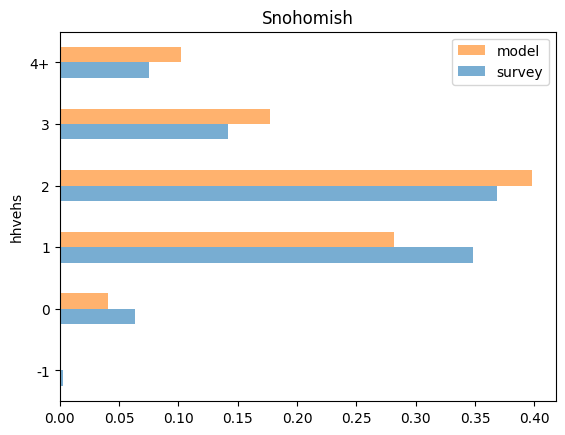

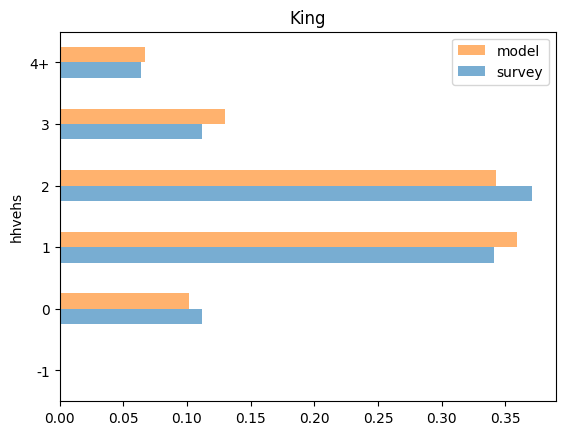

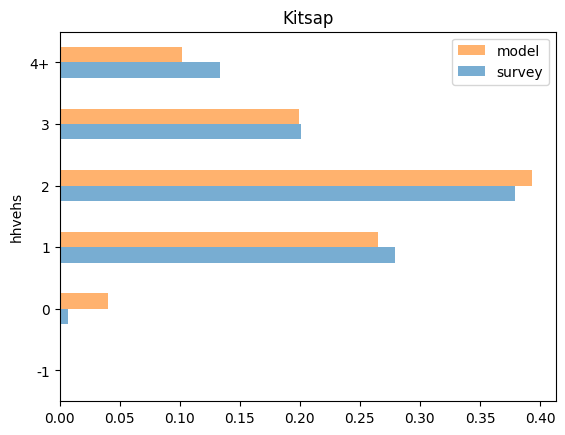

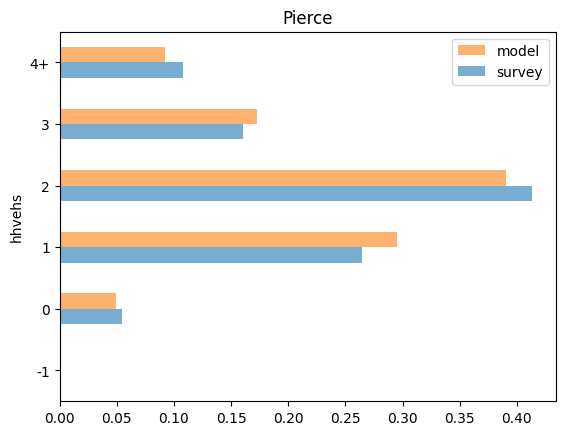

In [16]:
for county in df['hh_county'].unique():
    if county != 'Outside Region':
        _df = pd.DataFrame([_df_survey[county],_df_model[county]]).T
        _df.columns = ['survey','model']
        _df.plot(kind='barh', title=county, legend='reverse', alpha=0.6)


## Total Workers by Home County
Model

In [17]:
df = load_data('work_flows')
pd.options.display.float_format = '{:0,.0f}'.format
df.rename(columns={'person_county': 'Home County', 'person_work_county':'Work County'}, inplace=True)

pd.pivot_table(df[df['source'] == 'model'], index='Home County', columns='Work County', aggfunc='sum')

psexpfac                          source                \
Work County         King Kitsap  Pierce Snohomish   King Kitsap Pierce   
Home County                                                              
King           1,158,407  1,317  49,269    53,714  model  model  model   
Kitsap            14,213 94,088  11,339       936  model  model  model   
Outside Region       NaN      1     NaN       NaN    NaN  model    NaN   
Pierce           109,128  6,412 294,472     1,360  model  model  model   
Snohomish        145,914    121     941   285,313  model  model  model   

                          
Work County    Snohomish  
Home County               
King               model  
Kitsap             model  
Outside Region       NaN  
Pierce             model  
Snohomish          model